In [59]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)


In [60]:
db_path = "../data/greenhouse.db"  # adjust if needed

conn = sqlite3.connect(db_path)

df = pd.read_sql(
    """
    SELECT
        fecha_hora,
        medida,
        value_min,
        value_avg,
        value_max
    FROM vw_medidas_unidas_bi
    """,
    conn,
    parse_dates=["fecha_hora"]
)

conn.close()

df.head()


,fecha_hora,medida,value_min,value_avg,value_max
0,2025-11-29 14:00:00,Humidity 1,45.0,48.289474,51.5
1,2025-11-29 15:00:00,Humidity 1,51.9,61.883607,67.1
2,2025-11-29 16:00:00,Humidity 1,67.3,77.415847,86.6
3,2025-11-29 17:00:00,Humidity 1,86.8,90.129121,93.4
4,2025-11-29 18:00:00,Humidity 1,93.4,94.733333,95.6


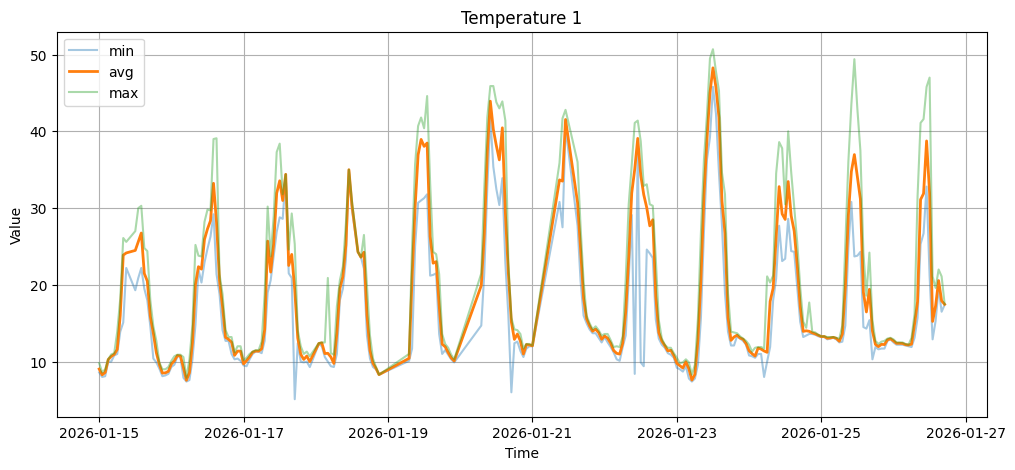

In [61]:
sensor = "Temperature 1"  # or any sensor / weather variable

df_f = df[(df["medida"] == sensor) & (df["fecha_hora"] >= '2026-01-15')].sort_values("fecha_hora")

plt.plot(df_f["fecha_hora"], df_f["value_min"], label="min", alpha=0.4)
plt.plot(df_f["fecha_hora"], df_f["value_avg"], label="avg", linewidth=2)
plt.plot(df_f["fecha_hora"], df_f["value_max"], label="max", alpha=0.4)

plt.title(sensor)
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [71]:
medidas = [
    "Temperature 1",
    "Temperature 2",
    "w_temp"
]

df_f = df[(df["fecha_hora"] >= '2026-01-20') & (df["fecha_hora"] < '2026-01-22')].sort_values("fecha_hora")
df_plot = df_f[df_f["medida"].isin(medidas)].copy()


In [74]:
df_plot["fecha_hora"] = pd.to_datetime(df_plot["fecha_hora"])
df_pivot = (
    df_plot
    .pivot_table(
        index="fecha_hora",
        columns="medida",
        values="value_avg"
    )
    .sort_index()
)
df_pivot.head(48)

medida,Temperature 1,Temperature 2,w_temp
fecha_hora,,,
2026-01-20 00:00:00,NaN,NaN,12.841001
2026-01-20 01:00:00,NaN,NaN,12.791000
2026-01-20 02:00:00,NaN,NaN,12.091001
2026-01-20 03:00:00,NaN,NaN,12.391000
2026-01-20 04:00:00,NaN,NaN,12.391000
2026-01-20 05:00:00,NaN,NaN,11.891000
2026-01-20 06:00:00,NaN,NaN,11.641000
2026-01-20 07:00:00,19.916071,17.229268,11.141000
2026-01-20 08:00:00,26.647333,23.132192,13.141000


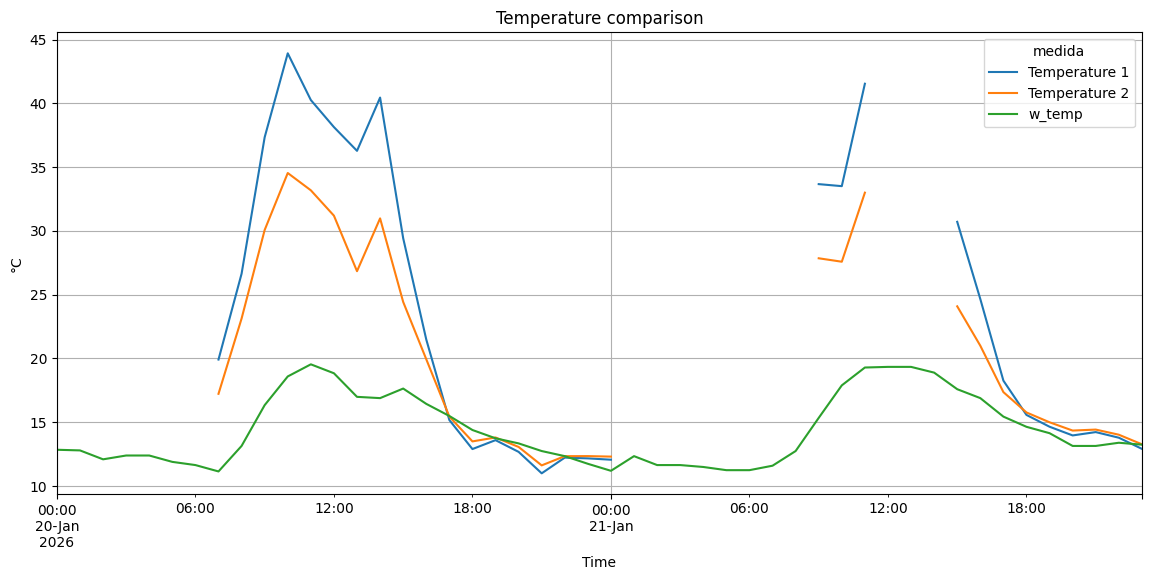

In [73]:
ax = df_pivot.plot(figsize=(14, 6))
ax.set_title("Temperature comparison")
ax.set_xlabel("Time")
ax.set_ylabel("°C")
ax.grid(True)